# Spectrogram-oriented noise for anomaly maps (study notebook)

Goal: explore a **Perlin-like** random field tailored to mel spectrograms before moving logic into `src/`. The production path will **binarize / threshold** a continuous noise map into a binary anomaly mask.

**Design axes (maximize randomization):**

1. **Frequency** — sample one or more mel bands with **variable bandwidth** (narrow to full-span), analogous to choosing where blobs appear in 2D Perlin.
2. **Time** — sample **several segments** with **variable count and lengths** (non-overlapping by default; optional jitter), similar to the spatial variety of Perlin blobs.
3. **Within each segment** — fill **consecutive frames** with a **time process** that mixes smooth (1D Perlin / cosine envelopes), piecewise (runs, steps), and rough components so adjacent frames are correlated but not identical.

This notebook keeps all generators **self-contained** for experimentation; later we can factor the chosen recipe into a module next to `perlin.py`.

## 1. Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

_cwd = Path(".").resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
sys.path.insert(0, str(PROJECT_ROOT))

import math
import numpy as np
import matplotlib.pyplot as plt

from src.utils.anomalies.perlin import rand_perlin_2d_np

RNG = np.random.default_rng(42)

n_mels = 128
T = 320
spectrogram_shape = (n_mels, T)

## 2. Baseline: 2D Perlin on `(n_mels, T)`

Same field as `_perlin_mask` uses: smooth blobs in **both** frequency and time. Our spectrogram-specific map will **constrain energy to chosen bands and time segments**, then apply **temporal** structure inside each segment.

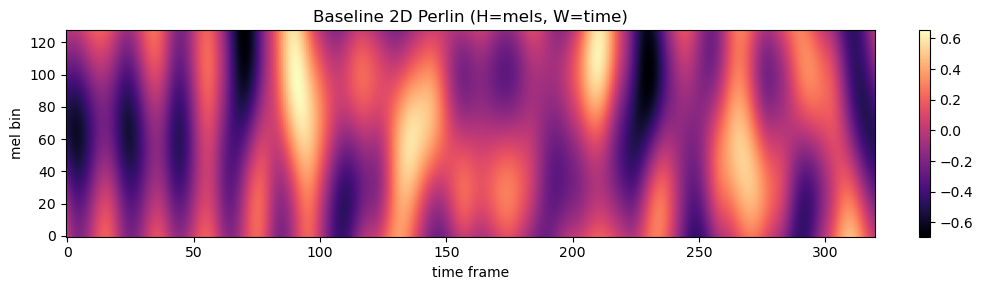

In [2]:
def baseline_perlin_2d(n_mels: int, T: int, rng: np.random.Generator) -> np.ndarray:
    """Mimic anomaly_map coarse scales: powers-of-two grid resolution."""
    min_exp, max_exp = 0, 5
    sy = 2 ** int(rng.integers(min_exp, max_exp + 1))
    sy = max(1, min(sy, n_mels))
    lo = int(math.log2(sy)) if sy > 0 else 0
    sx = 2 ** int(rng.integers(lo, max_exp + 1))
    sx = max(1, min(sx, T))
    return rand_perlin_2d_np((n_mels, T), (sy, sx))


p2 = baseline_perlin_2d(n_mels, T, RNG)
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
im = ax.imshow(p2, aspect="auto", origin="lower", cmap="magma")
ax.set_title("Baseline 2D Perlin (H=mels, W=time)")
ax.set_xlabel("time frame")
ax.set_ylabel("mel bin")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 3. Prototype: band × segments × temporal augmentation

**Continuous map** `M ∈ ℝ^{n_mels × T}` (later: threshold → binary mask).

- **Bands**: sample `num_bands ∈ [1, K]`; each band has random height `h ∈ [h_min, n_mels]` and start `i0` so `0 ≤ i0 < i0+h ≤ n_mels`. Optionally allow **partial overlap** between bands.
- **Segments**: partition or sample **non-overlapping** intervals along time (or leave gaps). Number of segments and lengths drawn from heavy-tailed / uniform mixes so layout resembles multiple blobs.
- **Per segment, per band**: build a length-`L` vector by blending:
  - 1D Perlin / smooth noise along the segment axis,
  - optional **envelope** (Hann, linear ramp),
  - optional **piecewise constant** runs (renewal-like),
  - optional **i.i.d. micro** noise for frame-to-frame variety.

Weights and which modes are active are randomized per segment.

In [3]:
def rand_perlin_1d(length: int, grid_cells: int, rng: np.random.Generator) -> np.ndarray:
    """1D Perlin by slicing 2D noise (one row)."""
    length = max(1, int(length))
    g = max(1, min(int(grid_cells), length))
    row = rand_perlin_2d_np((1, length), (1, g))[0]
    row = (row - row.mean()) / (row.std() + 1e-6)
    return row.astype(np.float32)


def sample_time_segments(
    T: int,
    rng: np.random.Generator,
    num_segments: int | None = None,
    min_cover_frac: float = 0.15,
    max_cover_frac: float = 0.85,
) -> list[tuple[int, int]]:
    """
    Non-overlapping half-open intervals [t0, t1) along [0, T).
    Random number of segments and random lengths (blob-like variety).
    """
    T = int(T)
    if T < 2:
        return [(0, T)]
    if num_segments is None:
        num_segments = int(rng.integers(1, min(8, max(2, T // 8)) + 1))
    num_segments = max(1, min(num_segments, T // 2))

    cover = rng.uniform(min_cover_frac, max_cover_frac)
    total_active = max(1, int(round(cover * T)))

    cuts = sorted(rng.choice(np.arange(1, T), size=num_segments - 1, replace=False).tolist())
    boundaries = [0] + cuts + [T]
    raw_lens = [boundaries[i + 1] - boundaries[i] for i in range(len(boundaries) - 1)]

    weights = np.array(raw_lens, dtype=np.float64) ** rng.uniform(0.4, 1.6)
    weights = weights / weights.sum()
    lens = np.maximum(1, np.round(weights * total_active).astype(int))
    delta = int(lens.sum() - total_active)
    if delta > 0:
        for _ in range(delta):
            j = int(np.argmax(lens))
            if lens[j] > 1:
                lens[j] -= 1
    elif delta < 0:
        for _ in range(-delta):
            j = int(rng.integers(0, len(lens)))
            lens[j] += 1

    order = rng.permutation(len(lens))
    segments: list[tuple[int, int]] = []
    cursor = 0
    for idx in order:
        L = int(lens[idx])
        if cursor + L > T:
            L = T - cursor
        if L <= 0:
            break
        segments.append((cursor, cursor + L))
        cursor += L
    if cursor < T and segments:
        t0, t1 = segments[-1]
        segments[-1] = (t0, T)
    segments.sort(key=lambda x: x[0])
    return segments


def sample_mel_bands(
    n_mels: int,
    rng: np.random.Generator,
    num_bands: int | None = None,
    min_band: int = 1,
) -> list[tuple[int, int]]:
    """Half-open mel index ranges [i0, i1) with random widths up to full height."""
    n_mels = int(n_mels)
    if num_bands is None:
        num_bands = int(rng.integers(1, min(5, max(2, n_mels // 8)) + 1))
    bands: list[tuple[int, int]] = []
    for _ in range(num_bands):
        h = int(rng.integers(min_band, n_mels + 1))
        h = min(h, n_mels)
        i0 = int(rng.integers(0, max(1, n_mels - h + 1)))
        i1 = i0 + h
        bands.append((i0, i1))
    return bands


def temporal_profile(L: int, rng: np.random.Generator) -> np.ndarray:
    """
    Length-L vector for one band inside one time segment.
    Mixes smooth 1D Perlin, envelope, renewal-like steps, micro noise.
    """
    L = max(1, int(L))
    g = int(rng.integers(1, max(2, min(L, 12))))
    smooth = rand_perlin_1d(L, g, rng)

    micro = rng.normal(0.0, 1.0, size=L).astype(np.float32)
    micro_scale = float(10 ** rng.uniform(-2.0, 0.0))

    env_mode = rng.choice(["none", "hann", "ramp_up", "ramp_down", "triangle"])
    t = np.linspace(0.0, 1.0, L, dtype=np.float32)
    if env_mode == "none":
        env = np.ones(L, dtype=np.float32)
    elif env_mode == "hann":
        env = np.sin(math.pi * t).astype(np.float32)
    elif env_mode == "ramp_up":
        env = t
    elif env_mode == "ramp_down":
        env = (1.0 - t).astype(np.float32)
    else:
        env = np.minimum(t, 1.0 - t) * 2.0

    steps = np.ones(L, dtype=np.float32)
    if rng.random() < 0.55:
        p = float(rng.uniform(0.08, 0.45))
        k = 0
        while k < L:
            run = int(rng.geometric(p))
            run = max(1, min(run, L - k))
            steps[k : k + run] = float(rng.normal(0, 1))
            k += run
        steps = (steps - steps.mean()) / (steps.std() + 1e-6)

    w_smooth = float(rng.uniform(0.2, 1.0))
    w_step = float(rng.uniform(0.0, 0.9))
    w_micro = float(rng.uniform(0.0, 0.85))
    v = w_smooth * smooth + w_step * steps + w_micro * micro_scale * micro
    v = v * env
    v = (v - v.mean()) / (v.std() + 1e-6)
    return v.astype(np.float32)


def spectrogram_structured_noise(
    n_mels: int,
    T: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Continuous noise map; threshold externally for binary anomaly mask.
    """
    M = np.zeros((n_mels, T), dtype=np.float32)
    bands = sample_mel_bands(n_mels, rng)
    segments = sample_time_segments(T, rng)

    for i0, i1 in bands:
        band_gain = float(10 ** rng.uniform(-0.35, 0.35))
        for t0, t1 in segments:
            L = t1 - t0
            if L < 1:
                continue
            col = temporal_profile(L, rng) * band_gain
            # Optional cross-band coupling: same time seg gets tiny 2D jitter
            if rng.random() < 0.25:
                jitter = rand_perlin_2d_np((i1 - i0, L), (max(1, (i1 - i0) // 4), max(1, L // 6)))
                jitter = (jitter - jitter.mean()) / (jitter.std() + 1e-6)
                col_2d = col[np.newaxis, :] + 0.35 * jitter
            else:
                row_noise = rand_perlin_1d(L, max(1, L // 5), rng)[np.newaxis, :]
                freq_shape = (i1 - i0, 1)
                freq_mod = rand_perlin_2d_np(freq_shape, (max(1, freq_shape[0] // 3), 1))
                freq_mod = (freq_mod - freq_mod.mean()) / (freq_mod.std() + 1e-6)
                col_2d = col[np.newaxis, :] * (0.65 + 0.35 * freq_mod) + 0.2 * row_noise

            M[i0:i1, t0:t1] += col_2d.astype(np.float32)

    if M.std() > 1e-6:
        M = (M - M.mean()) / M.std()
    return M.astype(np.float32)

## 4. Visual comparison: many draws

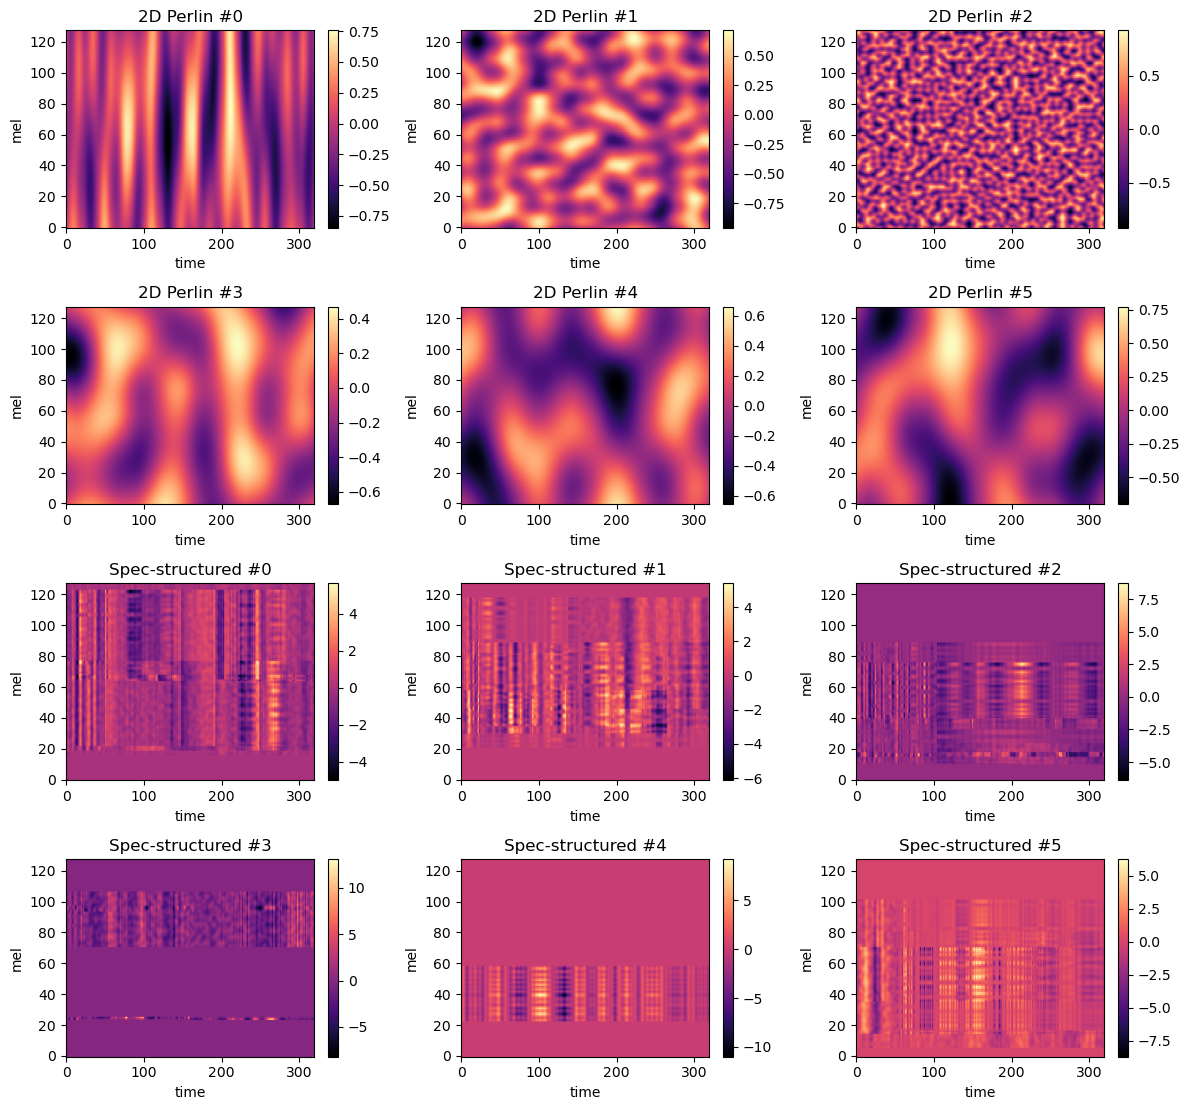

In [4]:
def plot_grid(maps: list[np.ndarray], titles: list[str], ncols: int = 3):
    n = len(maps)
    nrows = int(math.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.8 * nrows), squeeze=False)
    for k, ax in enumerate(axes.ravel()):
        if k < n:
            im = ax.imshow(maps[k], aspect="auto", origin="lower", cmap="magma")
            ax.set_title(titles[k])
            ax.set_xlabel("time")
            ax.set_ylabel("mel")
            plt.colorbar(im, ax=ax, fraction=0.046)
        else:
            ax.axis("off")
    plt.tight_layout()
    plt.show()


rng_demo = np.random.default_rng(123)
n_samples = 6
perlin_maps = [baseline_perlin_2d(n_mels, T, rng_demo) for _ in range(n_samples)]
spec_maps = [spectrogram_structured_noise(n_mels, T, rng_demo) for _ in range(n_samples)]

plot_grid(
    perlin_maps + spec_maps,
    [f"2D Perlin #{i}" for i in range(n_samples)] + [f"Spec-structured #{i}" for i in range(n_samples)],
    ncols=3,
)

## 5. Binarization / threshold sweep

The structured map is **continuous**; anomaly masks are **binary**. Below: global quantile thresholding (fixed fraction of active pixels) vs a fixed raw cutoff on standardized maps.

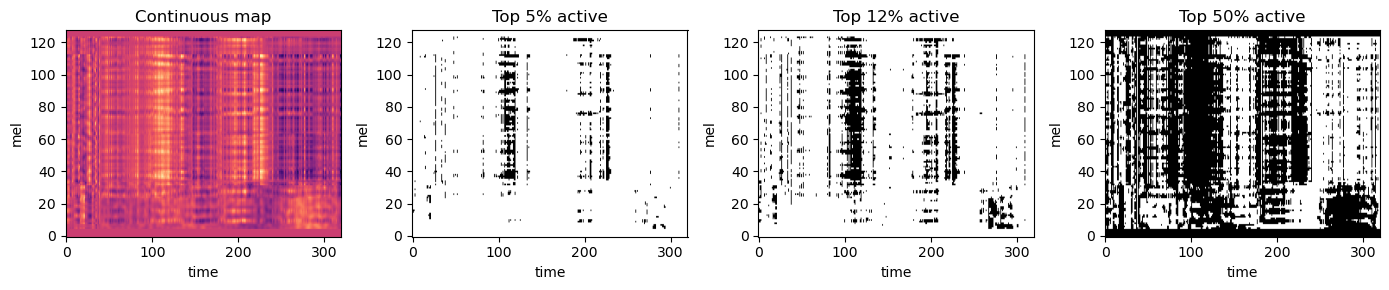

In [ ]:
def binarize_quantile(M: np.ndarray, q: float) -> np.ndarray:
    """Top q fraction of values set to 1 (per-map)."""
    thr = np.quantile(M, 1.0 - q)
    return (M >= thr).astype(np.float32)


rng_b = np.random.default_rng(7)
M = spectrogram_structured_noise(n_mels, T, rng_b)
qs = [0.05, 0.12, 0.25]

fig, axes = plt.subplots(1, len(qs) + 1, figsize=(14, 3))
axes[0].imshow(M, aspect="auto", origin="lower", cmap="magma")
axes[0].set_title("Continuous map")
for ax, q in zip(axes[1:], qs):
    ax.imshow(binarize_quantile(M, q), aspect="auto", origin="lower", cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(f"Top {100*q:.0f}% active")
for ax in axes:
    ax.set_xlabel("time")
    ax.set_ylabel("mel")
plt.tight_layout()
plt.show()

## 6. Notes for a future `src` module

- **Hz-aware bands**: reuse `_hz_band_to_mel_bins` / `_sample_mel_band` from `anomaly_map.py` so bandwidth matches physical mel filterbank limits.
- **Overlap policy**: current segments are a **scrambled partition** with random total cover; alternatives include **Poisson disk**-style minimum gaps or **allowed overlaps** for denser masks.
- **Latent projection**: if masks are applied in VQ space, study `project_spec_mask_to_latent_binary` (see `anomaly_mask_analysis.ipynb`) once the continuous map is frozen.
- **Correlation with 2D Perlin**: optional **add / max** with low-weight `rand_perlin_2d_np` to recover occasional full-grid blobs.

Run this notebook with different `n_mels`, `T`, and RNG seeds to stress-test edge cases (very small `T`, single-bin bands, etc.) before codifying defaults.